In [19]:
import numpy as np                                          # Μαθηματική/αριθμητική βιβλιοθήκη
import scipy.io.wavfile as wav                              # Βιβλιοθήκη ανάγνωσης/εγγραφής ήχου
import matplotlib.pyplot as plt                             # Βιβλιοθήκη απεικονίσεων

## Άσκηση - Πώς καταλαβαίνει το κινητό μας τηλέφωνο πότε μιλάμε και πότε όχι?

Μόνο και μόνο με τις έννοιες της *ενέργειας* και των απλών πρότυπων σημάτων, όπως ο *τετραγωνικός παλμός*, που έχετε μάθει σε αυτό το Κεφάλαιο, μπορείτε να δείτε μερικές εφαρμογές όπως η 
<center><font size=6>
Aνίχνευση δραστηριότητας ομιλίας - voice activity detection. 
</center>
<font size=4>
Αλγόριθμοι που υλοποιούν τέτοιες εφαρμογές υπάρχουν σε κάθε κινητό τηλέφωνο, όπως επίσης και σε συστήματα αναγνώρισης ομιλίας όπως η Siri, το Google Assistant, και η Amazon Alexa, αλλά και σε συστήματα επικοινωνιών όπως το Zoom, το Skype, και το Microsoft Teams.

Μια *ιδιαίτερα* απλοϊκή υλοποίηση ενός τέτοιου αλγορίθμου είναι η εξής :
- Διαβάζετε ένα αρχείο ομιλίας στην Python που σας δίνεται.
- Παραθυροποιείτε με χρήση τετραγωνικού παλμού το σήμα σας, "κόβοντας" έτσι ένα τμήμα του.
    - Θεωρητικά, αυτό αντιστοιχεί σε πολλαπλασιασμό του σήματος με ένα τετραγωνικό παλμό ($\mathrm{rect}(\cdot)$)
    - Η παραθυροποίηση γίνεται πρακτικά έμμεσα, απομονώνοντας ένα κομμάτι του σήματος μέσω array slicing. 
        - Άρα πρακτικά δεν πολλαπλασιάζουμε κάποιο σήμα με τον τετραγωνικό παλμό, αλλά **θεωρούμε** ότι το κάνουμε για να καταλάβουμε περισσότερα όσον αφορά το χώρο της συχνότητας, που θα ακολουθήσει αργότερα στο μάθημα.
        - Αν όμως το παράθυρό μας είναι ένας άλλος παλμός, π.χ. τριγωνικός, τότε **ναι**, γίνεται **ρητά** ο πολλαπλασιασμός του τμήματος του σήματος με τον τριγωνικό παλμό. 
- Για κάθε παραθυροποιημένο σήμα, υπολογίζετε την ενέργεια του από τη γνωστή σχέση της θεωρίας.
- Ανάλογα με την τιμή της ενέργειας, αποφασίζετε αν το παραθυροποιημένο σήμα περιέχει ομιλία ή όχι.
- Προχωράτε στο επόμενο παραθυροποιημένο σήμα και επαναλαμβάνετε, ως το τέλος του σήματος.

Ερωτήματα που προκύπτουν από την ανάγνωση του παραπάνω αλγορίθμου:

(α') Πόση είναι η διάρκεια του παραθυροποιημένου σήματος; Μια τιμή κοντά στα $0.03$ s $=30$ ms είναι καλή. Δεν υπάρχει βέλτιστη διάρκεια, υπάρχουν trade-offs είτε έχει μεγάλη είτε μικρή διάρκεια.

(β') Πόση απόσταση ϑα έχουν τα διαδοχικά παραθυροποιημένα σήματα μεταξύ τους; Στην πράξη, θα πρέπει όχι απλά να είναι διαδοχικά, αλλά να έχουν και κάποιο *ποσοστό επικάλυψης*. Για τους δικούς μας σκοπούς, θα χρησιμοποιήσουμε $0\%$ επικάλυψη, δηλ. τα παραθυροποιημένα σήματα θα είναι ακριβώς διαδοχικά, χωρίς "κενά" μεταξύ τους (αφού κάτι τέτοιο θα σήμαινε απώλεια εκτίμησης δραστηριότητας ομιλίας).

(γ') Πώς αποφασίζω με ϐάση την ενέργεια αν το εκάστοτε παραθυροποιημένο σήμα είναι τμήμα ομιλίας; Αυτή είναι μια ερώτηση που δέχεται αρκετές απαντήσεις - προσεγγίσεις. Ξανά μια απλή προσέγγιση είναι ότι στην αρχή του σήματος, υπάρχουν μερικά δευτερόλεπτα σιωπής - μπορείτε να εκτιμήσετε την ενέργεια σε αυτά τα παραθυροποιημένα σήματα και να αποφασίζετε ϐάσει αυτής (με κάποιο στατιστικό κριτήριο, όπως για παράδειγμα "*κάθε παραθυροποιημένο σήμα να έχει ενέργεια μεγαλύτερη του διπλάσιου της ενέργειας των παραθυροποιημένων σημάτων σιωπής*") για τα επόμενα τμήματα ομιλίας.

Το παρακάτω σχήμα δείχνει την τμηματοποίηση και τον υπολογισμό ενέργειας για κάθε παράθυρο (frame) σήματος.

<p style="text-align: center"><img src="./files/rectwindows.png" width="1400"></p>

<p style="text-align: center">Σχήμα 1: Τμηματοποίηση ομιλίας σε μη επικαλυπτόμενα παράθυρα (frames).</p>

Αν και υπάρχει ξεχωριστή εξίσωση για τον υπολογισμό της ενέργειας ενός σήματος **διακριτού χρόνου** (και θα τη δείτε σε επόμενα Κεφάλαια), όπως ένα .WAV αρχείο, θα χρησιμοποιήσουμε το ολοκλήρωμα Riemann για να υπολογίσουμε την ενέργεια, όπως είδατε στην προηγούμενη άσκηση (και θα δείτε και στο ακόλουθο toy example).

Το σήμα ομιλίας που έχουμε ηχογραφήσει και σας δίνουμε είναι *ψηφιακό* και όταν το διαβάζετε στην `Python`, το μετατρέπετε σε *διακριτού χρόνου*, αποθηκεύοντας τα δείγματά του σε ένα διάνυσμα. 

Μέχρι τότε όμως, ας καταλάβουμε λίγο τι συμβαίνει με ένα πιο ελεγχόμενο toy-παράδειγμα. Έστω ότι το σήμα ομιλίας διακριτού χρόνου που διαβάζετε είναι η ακολουθία από αριθμούς αποθηκευμένους στο διάνυσμα ```x``` όπως παρακάτω. Ας το δούμε.

Το σήμα ομιλίας διακριτού χρόνου είναι το x = [ 1.   0.5  1.2 -1.7  2.4 -0.3 -1.1  0.6 -0.9]


Text(0, 0.5, 'Πλάτος σήματος')

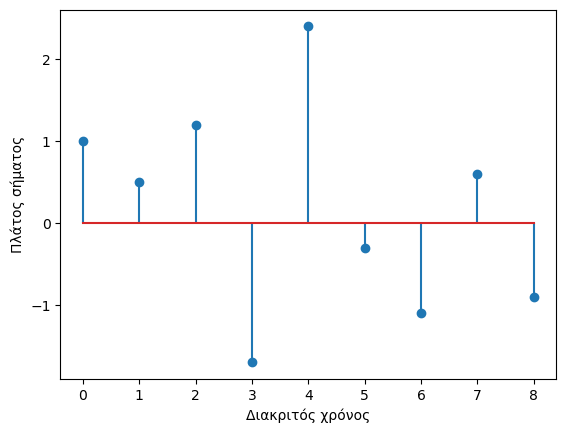

In [20]:
x = np.asarray([1, 0.5, 1.2, -1.7, 2.4, -0.3, -1.1, 0.6, -0.9])  # τυχαίο σήμα - υποτίθεται σήμα ομιλίας

print(f"Το σήμα ομιλίας διακριτού χρόνου είναι το x = {x}")      # βλέπουμε τις τιμές του
plt.stem(np.arange(0,9), x)                                      # τυπώνουμε τις τιμές του
plt.xlabel('Διακριτός χρόνος')                                   # ομορφαίνουμε
plt.ylabel('Πλάτος σήματος')                                     # ομορφαίνουμε

Οι τιμές που βλέπετε αποτελούν **δείγματα** του σήματος ομιλίας συνεχούς χρόνου που καταγράφηκε. Τα δείγματα αυτά λήφθηκαν ανά $1/F_s$ δευτερόλεπτα πραγματικού χρόνου, με $F_s$ να είναι η συχνότητα δειγματοληψίας, που σας δίνεται έτοιμη κάθε φορά που ανοίγετε ένα αρχείο ήχου στην `Python`. Αν, για παράδειγμα, η συχνότητα δειγματοληψίας είναι $16000$ Hz, τότε το παραπάνω σήμα $9$ δειγμάτων προέρχεται από ένα σήμα συνεχούς χρόνου διάρκειας 

$$(9-1)/16000 = 8/16000 = 500 \text{ μs} = 0.5 \text{ ms} = 0.0005 \text{ s}$$

Πραγματικά πολύ μικρής διάρκειας, αλλά είπαμε: toy-παράδειγμα. 😉 

Για να φτάσουμε στα $30$ ms που αναφέρει παραπάνω η άσκηση, χρειαζόμαστε $481$ δείγματα - αφού $(481-1)/16000 = 0.03$ s $= 30$ ms. Ας συνεχίσουμε όμως σε αυτό το toy example και ας υποθέσουμε όμως ότι θέλουμε να υπολογίσουμε την ενέργεια ανά $187.5$ μs, δηλ. ανά μόλις $N=3$ δείγματα. Τότε θα χωρίσουμε το σήμα σε $N-$άδες (τριάδες, εν προκειμένω), που ουσιαστικά αυτό αντιστοιχεί σε διαδοχικούς πολλαπλασιασμούς με μη επικαλυπτόμενους τετραγωνικούς παλμούς μοναδιαίου πλάτους και διάρκειας $187.5$ μs, ήτοι διάρκειας $N$ (τριών) δειγμάτων. 

Έτσι προκύπτουν (δείτε ξανά το διάνυσμα ```x``` παραπάνω) τρεις τριάδες, $(1, 0.5, 1.2), (−1.7, 2.4,−0.3), (−1.1, 0.6,−0.9)$, που καθεμιά είναι ένα παράθυρο σήματος, και θα υπολογίσουμε την ενέργειά καθεμιάς. Θα χρησιμοποιήσουμε μία λίστα (https://www.w3schools.com/python/python_lists.asp) της `Python`, στην οποία μπορούμε να *προσαρτήσουμε* (append) οποιαδήποτε μεταβλητή οποιουδήποτε μεγέθους, για να κρατάμε την ενέργεια καθενός παραθύρου.

In [21]:
Fs = 16000   # Έστω μια συχνότητα δειγματοληψίας
Dt = 1/Fs    # Περίοδος δειγματοληψίας (κάθε πόσα δευτερόλεπτα πήραμε ένα δείγμα από την ηχογράφησή μας)
N = 3        # Διάρκεια παραθύρου σε δείγματα : αυτό αντιστοιχεί σε 187.5 μικρο-δευτερόλεπτα πραγματικού χρόνου

# Τμηματοποίηση σε διαδοχικές N-άδες και υπολογισμός ενέργειας τους
x1 = x[0:N]     # από 0 ως Ν-1
x2 = x[N:2*N]   # από Ν ως 2Ν-1
x3 = x[2*N:3*N] # από 2Ν ως 3Ν-1

E = [] # μια άδεια λίστα για να μαζεύουμε τις ενέργειες των Ν-άδων
E.append(Dt * np.sum(x1**2)) # Riemann άθροισμα για το 1ο τμήμα
E.append(Dt * np.sum(x2**2)) # Riemann άθροισμα για το 2ο τμήμα
E.append(Dt * np.sum(x3**2)) # Riemann άθροισμα για το 3ο τμήμα

print(f"E1 = {E[0]}\nE2 = {E[1]}\nE3 = {E[2]}") 
# θα πρέπει να λάβετε: 
# E1 = 0.000168125, 
# E2 = 0.000546249, 
# E3 = 0.00014875

E1 = 0.000168125
E2 = 0.0005462499999999999
E3 = 0.00014875


Βλέπετε ότι κάθε τμήμα από το αρχικό σήμα έχει διαφορετική τιμή για την ενέργειά του. 

Ας επιστρέψουμε τώρα στο πλήρες, πραγματικό παράδειγμα, όπου θα υλοποιήσουμε πιο αυτοματοποιημένα τα παραπάνω, καθώς και την επιλογή της δραστηριότητας ομιλίας με βάση την ενέργεια κάθε τμήματος σήματος.

Ας γράψουμε κώδικα που διαβάζει ένα σήμα φωνής και μας υπολογίζει ένα διάνυσμα της ενέργειάς του σε κάποιες χρονικές στιγμές που αντιστοιχούν στα κέντρα των παραθύρων που αναλύουμε.

Η ιδέα είναι η εξής:

- Το σήμα ομιλίας θα αποθηκευτεί σε ένα ``numpy`` array.
- Θα το προσπελαύνουμε ανά μη επικαλυπτόμενα τμήματα, χρησιμοποιώντας array slicing, όπως στο παραπάνω toy example.
- Για κάθε τμήμα, θα υπολογίζουμε την ενέργειά του.
- Θα την αποθηκεύουμε σε ένα άλλο array, με τέτοιο τρόπο ώστε η $i-$οστή τιμή του array να αντιστοιχεί στο $i-$οστό τμήμα.
- Μόλις μαζέψουμε όλες τις ενέργειας, θα αποφασίσουμε ένα κατώφλι (threshold) με το οποίο θα συγκρίνουμε αυτές τις τιμές για να ταξινομούμε κάθε frame που αντιστοιχεί στις υπολογισμένες ενέργειες στην κατηγορία "speech" ή "non-speech".

Συμπληρώστε τον παρακάτω σκελετό.

In [22]:
# Φόρτωση αρχείου ήχου στην Python (Fs είναι η συχνότητα δειγματοληψίας)
Fs, s = wav.read('./files/speech.wav')

# Βήμα στο χρόνο (κάθε πότε πήραμε δείγμα από την πραγματική ηχογράφηση? κάθε 1/Fs δευτερόλεπτα)
Dt = 1/Fs

# Κανονικοποίηση του σήματος σε πλάτη [-1,1] (τεχνική λεπτομέρεια, μην τη λάβετε υπ'όψη)
s = s/np.max(np.abs(s))

# θέλουμε παράθυρα 30 ms στο χρόνο, σε πόσα δείγματα αντιστοιχούν? Αν 1 δευτερόλεπτο αντιστοιχεί σε Fs δείγματα, πόσα δείγματα αντιστοιχούν σε 0.03 δευτερόλεπτα? Χρησιμοποιήστε τη round().
T = round(Fs*0.03)

# Συνολική διάρκεια σήματος
L = len(s)

# Πόσα παράθυρα διάρκειας T δειγμάτων που βρηκαμε παραπάνω, μη επικαλυπτόμενα, χωρούν σε όλο το σήμα διάρκειας L δειγμάτων? Χρησιμοποιήστε τη round().
N = round(L/T)

# Δέσμευση μνήμης - αντίστοιχο της calloc στη C
Energy = np.zeros(N)
Time = np.zeros(N)

for i in range(1, N):
    
    # Χρησιμοποιώντας το δείκτη i, τη διάρκεια T, και τον τελεστή int(), κόψτε κάθε φορά ένα τμήμα του σήματος s διάρκειας T
    windowed_speech = s[int(i*T):int((i+1)*T)]

    # Υπολογίστε την ενέργεια του τμήματος σήματος windowed_speech (όπως δείξαμε παραπάνω)
    Energy[i] = Dt*np.sum(windowed_speech**2)
    
    # Κέντρο του κάθε τμήματος (το δείγμα στη μέση του τμήματος, π.χ. ένα τμήμα διάρκειας 200 δειγμάτων έχει κέντρο το 100)
    Time[i] = round(i*T+T/2)

Ας επιλέξουμε κατώφλι απόφασης με βάση τα frames της σιωπής στην αρχή του αρχείου. Όπως είπαμε, τα πρώτα 2 δευτερόλεπτα της ηχογράφησης (δηλ. τα πρώτα $2\cdot F_s$ δείγματα) έχουν σιωπή. Συμπληρώστε κατάλληλα παρακάτω.

In [23]:
# Κατώφλι απόφασης
No_Silence_Frames = round(2*Fs/T)             # το πληθος των frames που αντιστοιχούν στα πρώτα 2 δευτερόλεπτα
Threshold = Energy[:No_Silence_Frames].mean() # έστω ότι το κατώφλι είναι η μέση ενέργεια αυτών των πρώτων frames που αντιστοιχούν στα πρώτα 2 seconds

# Δέσμευση μνήμης για το διάνυσμα απόφασης (διάνυσμα με μηδενικά)
D = np.zeros(N)

# Διατρέχετε το διάνυσμα της ενέργειας που υπολογίσαμε ανά frame στον προηγούμενο κώδικα και αποφασίζετε 
# - 1 αν η ενέργεια του i-οστού frame είναι > από το κατώφλι, 
# - 0 αν η αντίστοιχη ενέργεια για το i-οστό frame είναι < κατώφλι
for i in range(N):
    if Energy[i] > Threshold:
         D[i] = 1

Τώρα μπορούμε να "ενώσουμε" τις εκτιμήσεις μας και να απεικονίσουμε το αποτέλεσμα.

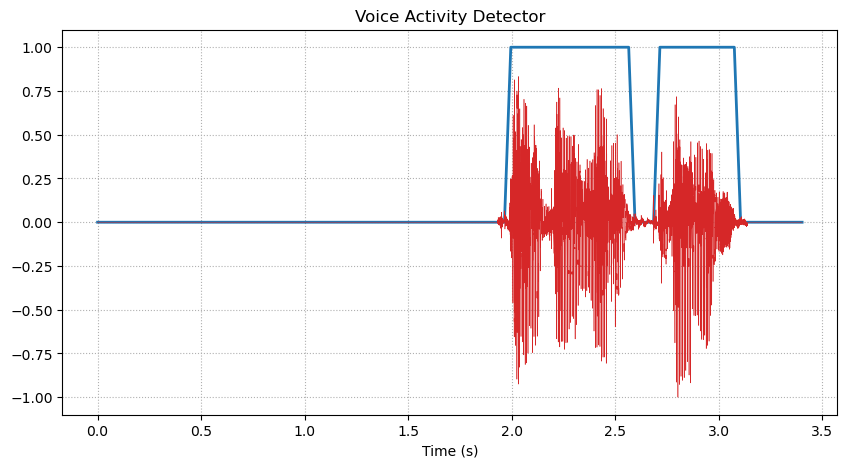

In [24]:
# Γράφημα
plt.figure(figsize=(10,5))

t = np.arange(start=0, stop=L*Dt, step=Dt)               # άξονας χρόνου με βήμα Dt
n = np.arange(start=0, stop=L, step=1)                   # άξονας διακριτού χρόνου για κάθε δείγμα
Din = np.interp(x=n, xp=Time, fp=D)                      # γραμμική παρεμβολή

plt.plot(t, Din, color='tab:blue', linewidth=2)            # γράφημα απόφασης
plt.plot(t, s/max(abs(s)), color='tab:red', linewidth=0.4) # γράφημα σήματος

plt.title('Voice Activity Detector')                     # Ομορφαίνουμε
plt.xlabel('Time (s)')                                   # --- " -----
plt.grid(linestyle=':')                                  # --- " -----

plt.show()

Αν τα κάνετε όλα σωστά, θα πάρετε κάτι **πολύ κοντά** στο παρακάτω σχήμα:

<p style="text-align: center"><img src="./files/VADoutput.png" width="800"></p>

α) Επαναλάβετε την παραπάνω άσκηση με χρήση της δικής σας φωνής! Ηχογραφήστε τον εαυτό σας, για 5-7 δευτερόλεπτα, λέγοντας μια τυχαία πρόταση μεγάλης διάρκειας αλλά <span style="font-size:1.5em;">κρατώντας τα δυο πρώτα δευτερόλεπτα σιωπηλά</span>. 

Χρησιμοποιήστε συχνότητα δειγματοληψίας $16000$ Hz, και μονοκαναλική ηχογράφηση. Προτεινόμενο πρόγραμμα ηχογράφησης: Audacity (https://www.audacityteam.org/)

Το παραγόμενο αρχείο πρέπει να μπει στον ίδιο κατάλογο με το παρόν .ipynb αρχείο, σε έναν υποκατάλογο ``files``.

<span style="font-size:1em;">Αν δεν το καταφέρετε, χρησιμοποιήστε το αρχείο `au-bout-du-telephone.wav` που σας δίνεται.</span>

C:\Users\kafge\AppData\Local\Temp\ipykernel_24224\2794776633.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, s = wav.read('./files/au-bout-du-telephone.wav')


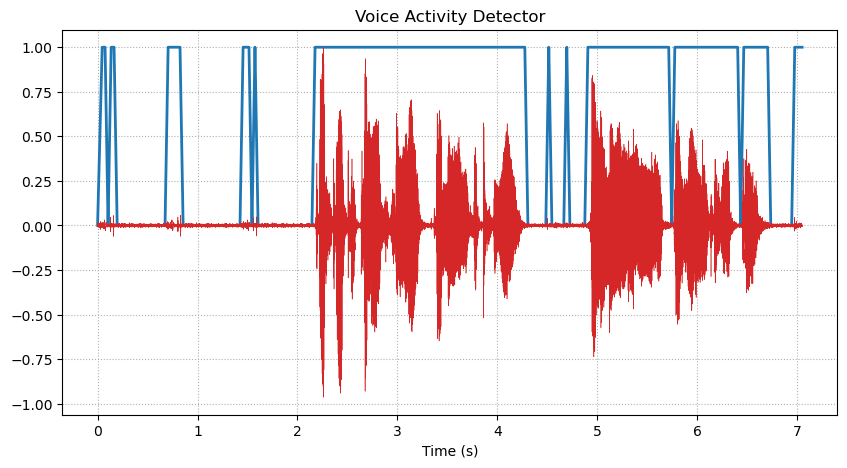

In [25]:
# INSERT CODE HERE
# Φόρτωση αρχείου ήχου στην Python (Fs είναι η συχνότητα δειγματοληψίας)
Fs, s = wav.read('./files/au-bout-du-telephone.wav')

# Βήμα στο χρόνο (κάθε πότε πήραμε δείγμα από την πραγματική ηχογράφηση? κάθε 1/Fs δευτερόλεπτα)
Dt = 1/Fs

# Κανονικοποίηση του σήματος σε πλάτη [-1,1] (τεχνική λεπτομέρεια, μην τη λάβετε υπ'όψη)
s = s/np.max(np.abs(s))

# θέλουμε παράθυρα 30 ms στο χρόνο, σε πόσα δείγματα αντιστοιχούν? Αν 1 δευτερόλεπτο αντιστοιχεί σε Fs δείγματα, πόσα δείγματα αντιστοιχούν σε 0.03 δευτερόλεπτα? Χρησιμοποιήστε τη round().
T = round(Fs*0.03)

# Συνολική διάρκεια σήματος
L = len(s)

# Πόσα παράθυρα διάρκειας T δειγμάτων που βρηκαμε παραπάνω, μη επικαλυπτόμενα, χωρούν σε όλο το σήμα διάρκειας L δειγμάτων? Χρησιμοποιήστε τη round().
N = round(L/T)

# Δέσμευση μνήμης - αντίστοιχο της calloc στη C
Energy = np.zeros(N)
Time = np.zeros(N)

for i in range(1, N):
    # Χρησιμοποιώντας το δείκτη i, τη διάρκεια T, και τον τελεστή int(), κόψτε κάθε φορά ένα τμήμα του σήματος s διάρκειας T
    windowed_speech = s[int(i*T):int((i+1)*T)]
    # Υπολογίστε την ενέργεια του τμήματος σήματος windowed_speech (όπως δείξαμε παραπάνω)
    Energy[i] = Dt*np.sum(windowed_speech**2)
    # Κέντρο του κάθε τμήματος (το δείγμα στη μέση του τμήματος, π.χ. ένα τμήμα διάρκειας 200 δειγμάτων έχει κέντρο το 100)
    Time[i] = round(i*T+T/2)

# Κατώφλι απόφασης
No_Silence_Frames = round(2*Fs/T)             # το πληθος των frames που αντιστοιχούν στα πρώτα 2 δευτερόλεπτα
Threshold = Energy[:No_Silence_Frames].mean() # έστω ότι το κατώφλι είναι η μέση ενέργεια αυτών των πρώτων frames που αντιστοιχούν στα πρώτα 2 seconds

# Δέσμευση μνήμης για το διάνυσμα απόφασης (διάνυσμα με μηδενικά)
D = np.zeros(N)

# Διατρέχετε το διάνυσμα της ενέργειας που υπολογίσαμε ανά frame στον προηγούμενο κώδικα και αποφασίζετε 
# - 1 αν η ενέργεια του i-οστού frame είναι > από το κατώφλι, 
# - 0 αν η αντίστοιχη ενέργεια για το i-οστό frame είναι < κατώφλι
for i in range(N):
    if Energy[i] > Threshold:
         D[i] = 1

# Γράφημα
plt.figure(figsize=(10,5))

t = np.arange(start=0, stop=L*Dt, step=Dt)               # άξονας χρόνου με βήμα Dt
n = np.arange(start=0, stop=L, step=1)                   # άξονας διακριτού χρόνου για κάθε δείγμα
Din = np.interp(x=n, xp=Time, fp=D)                      # γραμμική παρεμβολή

plt.plot(t, Din, color='tab:blue', linewidth=2)            # γράφημα απόφασης
plt.plot(t, s/max(abs(s)), color='tab:red', linewidth=0.4) # γράφημα σήματος

plt.title('Voice Activity Detector')                     # Ομορφαίνουμε
plt.xlabel('Time (s)')                                   # --- " -----
plt.grid(linestyle=':')                                  # --- " -----

plt.show()
# END OF CODE

β) Κάντε το ίδιο για τα δυο αρχεία που σας δίνονται, ``male_speech.wav`` και ``female_speech.wav``.

C:\Users\kafge\AppData\Local\Temp\ipykernel_24224\2136301965.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, s = wav.read('./files/male_speech.wav')


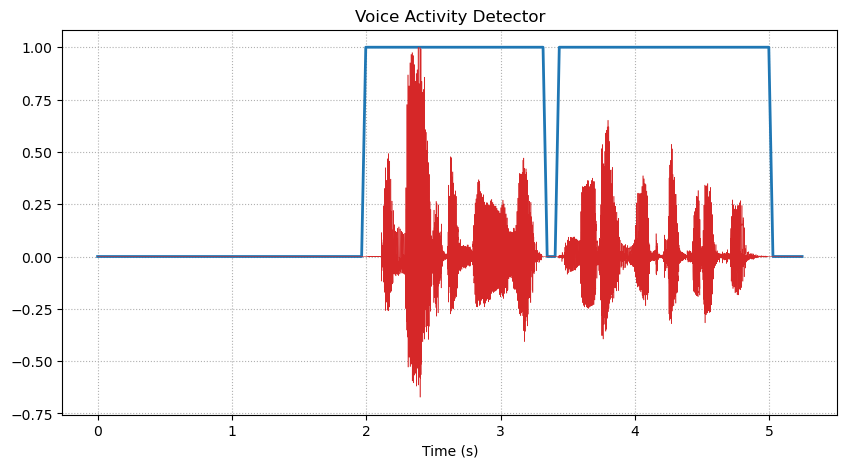

In [26]:
# INSERT CODE HERE
# Φόρτωση αρχείου ήχου στην Python (Fs είναι η συχνότητα δειγματοληψίας)
Fs, s = wav.read('./files/male_speech.wav')

# Βήμα στο χρόνο (κάθε πότε πήραμε δείγμα από την πραγματική ηχογράφηση? κάθε 1/Fs δευτερόλεπτα)
Dt = 1/Fs

# Κανονικοποίηση του σήματος σε πλάτη [-1,1] (τεχνική λεπτομέρεια, μην τη λάβετε υπ'όψη)
s = s/np.max(np.abs(s))

# θέλουμε παράθυρα 30 ms στο χρόνο, σε πόσα δείγματα αντιστοιχούν? Αν 1 δευτερόλεπτο αντιστοιχεί σε Fs δείγματα, πόσα δείγματα αντιστοιχούν σε 0.03 δευτερόλεπτα? Χρησιμοποιήστε τη round().
T = round(Fs*0.03)

# Συνολική διάρκεια σήματος
L = len(s)

# Πόσα παράθυρα διάρκειας T δειγμάτων που βρηκαμε παραπάνω, μη επικαλυπτόμενα, χωρούν σε όλο το σήμα διάρκειας L δειγμάτων? Χρησιμοποιήστε τη round().
N = round(L/T)

# Δέσμευση μνήμης - αντίστοιχο της calloc στη C
Energy = np.zeros(N)
Time = np.zeros(N)

for i in range(1, N):
    # Χρησιμοποιώντας το δείκτη i, τη διάρκεια T, και τον τελεστή int(), κόψτε κάθε φορά ένα τμήμα του σήματος s διάρκειας T
    windowed_speech = s[int(i*T):int((i+1)*T)]
    # Υπολογίστε την ενέργεια του τμήματος σήματος windowed_speech (όπως δείξαμε παραπάνω)
    Energy[i] = Dt*np.sum(windowed_speech**2)
    # Κέντρο του κάθε τμήματος (το δείγμα στη μέση του τμήματος, π.χ. ένα τμήμα διάρκειας 200 δειγμάτων έχει κέντρο το 100)
    Time[i] = round(i*T+T/2)

# Κατώφλι απόφασης
No_Silence_Frames = round(2*Fs/T)             # το πληθος των frames που αντιστοιχούν στα πρώτα 2 δευτερόλεπτα
Threshold = Energy[:No_Silence_Frames].mean() # έστω ότι το κατώφλι είναι η μέση ενέργεια αυτών των πρώτων frames που αντιστοιχούν στα πρώτα 2 seconds

# Δέσμευση μνήμης για το διάνυσμα απόφασης (διάνυσμα με μηδενικά)
D = np.zeros(N)

# Διατρέχετε το διάνυσμα της ενέργειας που υπολογίσαμε ανά frame στον προηγούμενο κώδικα και αποφασίζετε 
# - 1 αν η ενέργεια του i-οστού frame είναι > από το κατώφλι, 
# - 0 αν η αντίστοιχη ενέργεια για το i-οστό frame είναι < κατώφλι
for i in range(N):
    if Energy[i] > Threshold:
         D[i] = 1

# Γράφημα
plt.figure(figsize=(10,5))

t = np.arange(start=0, stop=L*Dt, step=Dt)               # άξονας χρόνου με βήμα Dt
n = np.arange(start=0, stop=L, step=1)                   # άξονας διακριτού χρόνου για κάθε δείγμα
Din = np.interp(x=n, xp=Time, fp=D)                      # γραμμική παρεμβολή

plt.plot(t, Din, color='tab:blue', linewidth=2)            # γράφημα απόφασης
plt.plot(t, s/max(abs(s)), color='tab:red', linewidth=0.4) # γράφημα σήματος

plt.title('Voice Activity Detector')                     # Ομορφαίνουμε
plt.xlabel('Time (s)')                                   # --- " -----
plt.grid(linestyle=':')                                  # --- " -----

plt.show()
# END OF CODE

C:\Users\kafge\AppData\Local\Temp\ipykernel_24224\52571932.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, s = wav.read('./files/female_speech.wav')


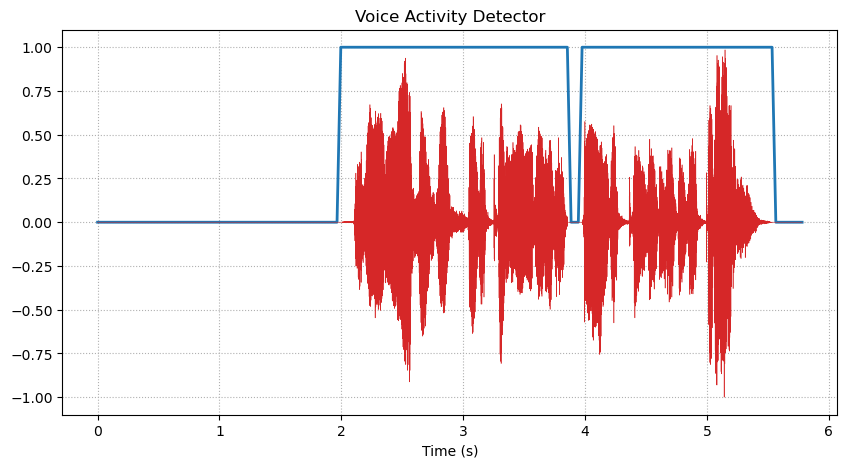

In [27]:
# INSERT CODE HERE
# Φόρτωση αρχείου ήχου στην Python (Fs είναι η συχνότητα δειγματοληψίας)
Fs, s = wav.read('./files/female_speech.wav')

# Βήμα στο χρόνο (κάθε πότε πήραμε δείγμα από την πραγματική ηχογράφηση? κάθε 1/Fs δευτερόλεπτα)
Dt = 1/Fs

# Κανονικοποίηση του σήματος σε πλάτη [-1,1] (τεχνική λεπτομέρεια, μην τη λάβετε υπ'όψη)
s = s/np.max(np.abs(s))

# θέλουμε παράθυρα 30 ms στο χρόνο, σε πόσα δείγματα αντιστοιχούν? Αν 1 δευτερόλεπτο αντιστοιχεί σε Fs δείγματα, πόσα δείγματα αντιστοιχούν σε 0.03 δευτερόλεπτα? Χρησιμοποιήστε τη round().
T = round(Fs*0.03)

# Συνολική διάρκεια σήματος
L = len(s)

# Πόσα παράθυρα διάρκειας T δειγμάτων που βρηκαμε παραπάνω, μη επικαλυπτόμενα, χωρούν σε όλο το σήμα διάρκειας L δειγμάτων? Χρησιμοποιήστε τη round().
N = round(L/T)

# Δέσμευση μνήμης - αντίστοιχο της calloc στη C
Energy = np.zeros(N)
Time = np.zeros(N)

for i in range(1, N):
    # Χρησιμοποιώντας το δείκτη i, τη διάρκεια T, και τον τελεστή int(), κόψτε κάθε φορά ένα τμήμα του σήματος s διάρκειας T
    windowed_speech = s[int(i*T):int((i+1)*T)]
    # Υπολογίστε την ενέργεια του τμήματος σήματος windowed_speech (όπως δείξαμε παραπάνω)
    Energy[i] = Dt*np.sum(windowed_speech**2)
    # Κέντρο του κάθε τμήματος (το δείγμα στη μέση του τμήματος, π.χ. ένα τμήμα διάρκειας 200 δειγμάτων έχει κέντρο το 100)
    Time[i] = round(i*T+T/2)

# Κατώφλι απόφασης
No_Silence_Frames = round(2*Fs/T)             # το πληθος των frames που αντιστοιχούν στα πρώτα 2 δευτερόλεπτα
Threshold = Energy[:No_Silence_Frames].mean() # έστω ότι το κατώφλι είναι η μέση ενέργεια αυτών των πρώτων frames που αντιστοιχούν στα πρώτα 2 seconds

# Δέσμευση μνήμης για το διάνυσμα απόφασης (διάνυσμα με μηδενικά)
D = np.zeros(N)

# Διατρέχετε το διάνυσμα της ενέργειας που υπολογίσαμε ανά frame στον προηγούμενο κώδικα και αποφασίζετε 
# - 1 αν η ενέργεια του i-οστού frame είναι > από το κατώφλι, 
# - 0 αν η αντίστοιχη ενέργεια για το i-οστό frame είναι < κατώφλι
for i in range(N):
    if Energy[i] > Threshold:
         D[i] = 1

# Γράφημα
plt.figure(figsize=(10,5))

t = np.arange(start=0, stop=L*Dt, step=Dt)               # άξονας χρόνου με βήμα Dt
n = np.arange(start=0, stop=L, step=1)                   # άξονας διακριτού χρόνου για κάθε δείγμα
Din = np.interp(x=n, xp=Time, fp=D)                      # γραμμική παρεμβολή

plt.plot(t, Din, color='tab:blue', linewidth=2)            # γράφημα απόφασης
plt.plot(t, s/max(abs(s)), color='tab:red', linewidth=0.4) # γράφημα σήματος

plt.title('Voice Activity Detector')                     # Ομορφαίνουμε
plt.xlabel('Time (s)')                                   # --- " -----
plt.grid(linestyle=':')                                  # --- " -----

plt.show()
# END OF CODE

---
---